# ClinVar Missense Variant Pathogenicity Classifier

Pipeline:
1. Parse & filter the ClinVar VCF (SNV, PAH / CFTR / hereditary, review ≥ 3 ★)
2. Engineer biochemical features (Δ hydrophobicity, Δ volume, Δ charge, Δ MW, Δ polarity, Grantham distance)
3. Extract population-frequency features (AF_ESP, AF_EXAC, AF_TGP)
4. Build a VEP input file → user uploads to Ensembl VEP web tool
5. After VEP results are returned: merge local-sequence-context + conservation + in-silico scores
6. Train & evaluate an ML classifier (Pathogenic vs Benign)

In [1]:

# ── Install dependencies (run once) ──────────────────────────────────────────
import subprocess, sys

packages = [
    "pandas", "numpy", "scikit-learn",
    "matplotlib", "seaborn", "xgboost", "lightgbm",
    "requests", "tqdm"
]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + packages)
print("✓ All packages installed")


✓ All packages installed


In [2]:

# ── Imports & configuration ───────────────────────────────────────────────────
import os, re, math, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)

# ── File paths ─────────────────────────────────────────────────────────────────
VCF_PATH   = r"c:\Users\Umut\Desktop\missense_classificaiton\clinvar_20260218.vcf"
VEP_IN     = r"c:\Users\Umut\Desktop\missense_classificaiton\vep_input.vcf"
VEP_OUT    = r"c:\Users\Umut\Desktop\missense_classificaiton\vep_output.txt"   # will exist after VEP upload

print(f"VCF path : {VCF_PATH}")
print(f"VEP input: {VEP_IN}")


VCF path : c:\Users\Umut\Desktop\missense_classificaiton\clinvar_20260218.vcf
VEP input: c:\Users\Umut\Desktop\missense_classificaiton\vep_input.vcf


## Amino‑acid Property Tables & Grantham Distance

In [3]:

# ── Amino-acid physicochemical properties ─────────────────────────────────────
# Sources:
#   Hydrophobicity : Kyte & Doolittle (1982)
#   Molecular weight: residue MW (Da)
#   Volume          : van-der-Waals volume (Å³), Richards (1974)
#   Charge          : net charge at pH 7.4
#   Polarity        : Zimmermann et al. (1968) polarity index

AA_PROPS = {
    #  1-letter   mw      hydro   charge  polarity  volume
    'A': dict(mw=89.09,  hydro= 1.8,  charge= 0,    polarity= 8.1,  volume= 88.6),
    'R': dict(mw=174.20, hydro=-4.5,  charge= 1.0,  polarity=10.5,  volume=173.4),
    'N': dict(mw=132.12, hydro=-3.5,  charge= 0,    polarity=11.6,  volume=114.1),
    'D': dict(mw=133.10, hydro=-3.5,  charge=-1.0,  polarity=13.0,  volume=111.1),
    'C': dict(mw=121.16, hydro= 2.5,  charge= 0,    polarity= 5.5,  volume=108.5),
    'Q': dict(mw=146.15, hydro=-3.5,  charge= 0,    polarity=10.5,  volume=143.8),
    'E': dict(mw=147.13, hydro=-3.5,  charge=-1.0,  polarity=12.3,  volume=138.4),
    'G': dict(mw= 75.03, hydro=-0.4,  charge= 0,    polarity= 9.0,  volume= 60.1),
    'H': dict(mw=155.16, hydro=-3.2,  charge= 0.1,  polarity=10.4,  volume=153.2),
    'I': dict(mw=131.17, hydro= 4.5,  charge= 0,    polarity= 5.2,  volume=166.7),
    'L': dict(mw=131.17, hydro= 3.8,  charge= 0,    polarity= 4.9,  volume=166.7),
    'K': dict(mw=146.19, hydro=-3.9,  charge= 1.0,  polarity=11.3,  volume=168.6),
    'M': dict(mw=149.21, hydro= 1.9,  charge= 0,    polarity= 5.7,  volume=162.9),
    'F': dict(mw=165.19, hydro= 2.8,  charge= 0,    polarity= 5.2,  volume=189.9),
    'P': dict(mw=115.13, hydro=-1.6,  charge= 0,    polarity= 8.0,  volume=112.7),
    'S': dict(mw=105.09, hydro=-0.8,  charge= 0,    polarity= 9.2,  volume= 89.0),
    'T': dict(mw=119.12, hydro=-0.7,  charge= 0,    polarity= 8.6,  volume=116.1),
    'W': dict(mw=204.23, hydro=-0.9,  charge= 0,    polarity= 5.4,  volume=227.8),
    'Y': dict(mw=181.19, hydro=-1.3,  charge= 0,    polarity= 6.2,  volume=193.6),
    'V': dict(mw=117.15, hydro= 4.2,  charge= 0,    polarity= 5.9,  volume=140.0),
}

# ── Grantham (1974) composition / polarity / volume ──────────────────────────
# Used only for the Grantham distance formula
GRANTHAM = {
    'A': dict(c=0,    p= 8.1, v= 31),
    'R': dict(c=0.65, p=10.5, v=124),
    'N': dict(c=1.33, p=11.6, v= 56),
    'D': dict(c=1.38, p=13.0, v= 54),
    'C': dict(c=2.75, p= 5.5, v= 55),
    'Q': dict(c=0.89, p=10.5, v= 85),
    'E': dict(c=0.92, p=12.3, v= 83),
    'G': dict(c=0.74, p= 9.0, v=  3),
    'H': dict(c=0.58, p=10.4, v= 96),
    'I': dict(c=0,    p= 5.2, v=111),
    'L': dict(c=0,    p= 4.9, v=111),
    'K': dict(c=0.33, p=11.3, v=119),
    'M': dict(c=0,    p= 5.7, v=105),
    'F': dict(c=0,    p= 5.2, v=132),
    'P': dict(c=0.39, p= 8.0, v= 32),
    'S': dict(c=1.42, p= 9.2, v= 32),
    'T': dict(c=0.71, p= 8.6, v= 61),
    'W': dict(c=0.13, p= 5.4, v=170),
    'Y': dict(c=0.20, p= 6.2, v=136),
    'V': dict(c=0,    p= 5.9, v= 84),
}

# Grantham formula constants  (Grantham 1974, Science 185:862–864)
_A, _B, _C = 1.833, 0.1018, 0.000399   # weight coefficients for c, p, v
# Normalisation: max(c)=2.75, max(p)=13.0, max(v)=170

def grantham_distance(aa1: str, aa2: str) -> float:
    """Return Grantham distance between two single-letter amino acids. NaN if unknown."""
    if aa1 not in GRANTHAM or aa2 not in GRANTHAM:
        return float("nan")
    a, b = GRANTHAM[aa1], GRANTHAM[aa2]
    return round(
        math.sqrt(
            _A * (a['c'] - b['c'])**2
            + _B * (a['p'] - b['p'])**2
            + _C * (a['v'] - b['v'])**2
        ),
        2
    )

# Three-letter → one-letter mapping (for HGVS protein notation)
AA3_TO_1 = {
    'Ala':'A','Arg':'R','Asn':'N','Asp':'D','Cys':'C','Gln':'Q','Glu':'E',
    'Gly':'G','His':'H','Ile':'I','Leu':'L','Lys':'K','Met':'M','Phe':'F',
    'Pro':'P','Ser':'S','Thr':'T','Trp':'W','Tyr':'Y','Val':'V','Ter':'*',
    'Sec':'U','Xaa':'X',
}

# Quick sanity check
print("Grantham Gly→Trp :", grantham_distance('G', 'W'))   # should be ~184
print("Grantham Ala→Val :", grantham_distance('A', 'V'))   # should be ~64


Grantham Gly→Trp : 3.62
Grantham Ala→Val : 1.27


## Step 1 — Parse ClinVar VCF into a DataFrame

The file is ~1.9 GB; we stream it line-by-line, parsing only the INFO field, so memory stays low.  
We keep every variant initially and apply filters in the next step.

In [4]:

def parse_info(info_str: str) -> dict:
    """Parse a VCF INFO field string into a flat Python dict."""
    d = {}
    for token in info_str.split(";"):
        if "=" in token:
            key, val = token.split("=", 1)
            d[key] = val
        else:
            d[token] = True          # flag fields
    return d

# INFO keys we want to keep (others will be dropped after flattening)
KEEP_INFO = [
    "AF_ESP", "AF_EXAC", "AF_TGP",
    "CLNDN", "CLNHGVS", "CLNREVSTAT", "CLNSIG", "CLNSIGCONF",
    "CLNVC", "GENEINFO", "MC", "ORIGIN", "RS",
]

records = []
total_lines = 0

print(f"Reading {VCF_PATH} …")
with open(VCF_PATH, "r", encoding="utf-8", errors="replace") as fh:
    for line in fh:
        if line.startswith("##"):
            continue                  # skip meta-info headers
        if line.startswith("#CHROM"):
            continue                  # skip column-header line
        
        total_lines += 1
        parts = line.rstrip("\n").split("\t")
        if len(parts) < 8:
            continue
        
        chrom, pos, var_id, ref, alt, qual, filt, info_str = parts[:8]
        info = parse_info(info_str)
        
        row = {
            "CHROM": chrom,
            "POS":   int(pos),
            "ID":    var_id,
            "REF":   ref,
            "ALT":   alt,
        }
        for k in KEEP_INFO:
            row[k] = info.get(k, None)
        
        records.append(row)

raw_df = pd.DataFrame(records)
print(f"Parsed {total_lines:,} variant lines → DataFrame shape: {raw_df.shape}")
raw_df.head(3)


Reading c:\Users\Umut\Desktop\missense_classificaiton\clinvar_20260218.vcf …
Parsed 4,352,930 variant lines → DataFrame shape: (4352930, 18)


,CHROM,POS,ID,REF,ALT,AF_ESP,AF_EXAC,AF_TGP,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,GENEINFO,MC,ORIGIN,RS
0,1,66926,3385321,AG,A,None,None,None,Retinitis_pigmentosa,NC_000001.11:g.66927del,"criteria_provided,_single_submitter",Uncertain_significance,None,Deletion,OR4F5:79501,SO:0001627|intron_variant,0,None
1,1,69134,2205837,A,G,None,None,None,not_specified,NC_000001.11:g.69134A>G,"criteria_provided,_single_submitter",Likely_benign,None,single_nucleotide_variant,OR4F5:79501,SO:0001583|missense_variant,1,781394307
2,1,69241,4562067,C,T,None,None,None,not_specified,NC_000001.11:g.69241C>T,"criteria_provided,_single_submitter",Uncertain_significance,None,single_nucleotide_variant,OR4F5:79501,SO:0001583|missense_variant,1,None


## Step 2 — Data Filtering

Order of filters:
1. Keep only **Single Nucleotide Variants** (`CLNVC = single_nucleotide_variant`)
2. Keep only **missense** variants (`MC` contains `missense_variant`)
3. Keep only variants with **ClinVar review star ≥ 3** (expert panel or practice guideline)
4. Keep only variants in **PAH** or **CFTR** genes, or diseases named "hereditary …"
5. Keep only **Pathogenic / Likely pathogenic / Benign / Likely benign** labels (drop VUS)
6. Drop columns that carry no predictive signal or genomic-address info

In [5]:

df = raw_df.copy()

# ── 2.1  SNV-only ─────────────────────────────────────────────────────────────
before = len(df)
df = df[df["CLNVC"] == "single_nucleotide_variant"].copy()
print(f"After SNV filter      : {len(df):,}  (removed {before - len(df):,})")

# ── 2.2  Missense-only ────────────────────────────────────────────────────────
before = len(df)
df = df[df["MC"].notna() & df["MC"].str.contains("missense_variant", na=False)].copy()
print(f"After missense filter : {len(df):,}  (removed {before - len(df):,})")

# ── 2.3  Review-star ≥ 3 ─────────────────────────────────────────────────────
# NOTE: CLNREVSTAT values contain internal commas (e.g. "criteria_provided,_single_submitter").
# They must NOT be split by comma — we do a direct string lookup instead.
REVSTAT_STARS = {
    "practice_guideline":                                       4,
    "reviewed_by_expert_panel":                                 3,
    "criteria_provided,_multiple_submitters,_no_conflicts":     2,
    "criteria_provided,_conflicting_interpretations":           1,
    "criteria_provided,_single_submitter":                      1,
    "no_assertion_criteria_provided":                           0,
    "no_criteria_provided":                                     0,
    "no_assertion_provided":                                    0,
    "no_interpretation_for_the_single_variant":                 0,
}

def revstat_to_stars(revstat) -> int:
    if pd.isna(revstat):
        return -1
    val = str(revstat).strip()
    # Direct match (ClinVar status values may contain commas internally)
    if val in REVSTAT_STARS:
        return REVSTAT_STARS[val]
    # Pipe-separated multiple statuses → take the maximum
    if "|" in val:
        parts = [REVSTAT_STARS.get(s.strip(), 0) for s in val.split("|")]
        return max(parts)
    return 0

df["review_stars"] = df["CLNREVSTAT"].apply(revstat_to_stars)
before = len(df)
df = df[df["review_stars"] >= 3].copy()
print(f"After ≥3-star filter  : {len(df):,}  (removed {before - len(df):,})")

# ── 2.4  Gene / disease filter: PAH, CFTR, or any hereditary condition ───────
def gene_filter(row) -> bool:
    geneinfo = str(row.get("GENEINFO", "") or "")
    clndn    = str(row.get("CLNDN",    "") or "")
    # Extract gene symbols (format: SYMBOL:gene_id|SYMBOL2:gene_id2)
    genes = [g.split(":")[0].upper() for g in geneinfo.split("|") if g]
    if "PAH" in genes or "CFTR" in genes:
        return True
    if re.search(r"hereditar", clndn, re.IGNORECASE):
        return True
    return False

before = len(df)
df = df[df.apply(gene_filter, axis=1)].copy()
print(f"After gene filter     : {len(df):,}  (removed {before - len(df):,})")

# ── 2.5  Keep only clear pathogenicity labels ─────────────────────────────────
PATHOGENIC_LABELS = {
    "Pathogenic", "Likely_pathogenic",
    "Pathogenic/Likely_pathogenic",
}
BENIGN_LABELS = {
    "Benign", "Likely_benign",
    "Benign/Likely_benign",
}
ALL_KEEP = PATHOGENIC_LABELS | BENIGN_LABELS

before = len(df)
df = df[df["CLNSIG"].isin(ALL_KEEP)].copy()
print(f"After P/B label filter: {len(df):,}  (removed {before - len(df):,})")

# ── 2.6  Drop unwanted columns ────────────────────────────────────────────────
# User requested removal of: AlleleID, VariationID (ID col), RS#, nsv/esv,
# OtherIDs, SCVs, PhenotypeIDs, PhenotypeList (CLNDN), CLNREVSTAT (used as
# stars already), CLNVCSO.
DROP_COLS = [
    "ID",               # VariationID
    "RS",               # dbSNP RS#
    "CLNREVSTAT",       # replaced by review_stars
    "CLNSIGCONF",       # conflicting submitter info
    "MC",               # used for filtering only
    "CLNVC",            # all remaining are SNVs
    "ORIGIN",           # most are germline by this point
    # NOTE: CHROM and POS are kept here; they will be dropped AFTER
    # the VEP input file is written in Step 5 below.
]
df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)

# Keep CLNDN for reference but will NOT be used as a model feature
print(f"\nFinal filtered shape  : {df.shape}")
print("Columns kept:", df.columns.tolist())
df.head(5)


After SNV filter      : 4,054,532  (removed 298,398)
After missense filter : 2,466,327  (removed 1,588,205)
After ≥3-star filter  : 7,467  (removed 2,458,860)
After gene filter     : 2,846  (removed 4,621)
After P/B label filter: 1,738  (removed 1,108)

Final filtered shape  : (1738, 12)
Columns kept: ['CHROM', 'POS', 'REF', 'ALT', 'AF_ESP', 'AF_EXAC', 'AF_TGP', 'CLNDN', 'CLNHGVS', 'CLNSIG', 'GENEINFO', 'review_stars']


,CHROM,POS,REF,ALT,AF_ESP,AF_EXAC,AF_TGP,CLNDN,CLNHGVS,CLNSIG,GENEINFO,review_stars
269495,1,173903968,G,A,None,None,None,Hereditary_antithrombin_deficiency,NC_000001.11:g.173903968G>A,Likely_pathogenic,SERPINC1:462,3
269498,1,173903969,G,T,None,None,None,Abnormal_thrombosis|Hereditary_antithrombin_deficiency,NC_000001.11:g.173903969G>T,Pathogenic,SERPINC1:462,3
269501,1,173903973,G,C,None,None,None,not_provided|Hereditary_antithrombin_deficiency,NC_000001.11:g.173903973G>C,Pathogenic,SERPINC1:462,3
269504,1,173903978,C,T,None,None,None,Hereditary_antithrombin_deficiency,NC_000001.11:g.173903978C>T,Likely_pathogenic,SERPINC1:462,3
269511,1,173904007,G,A,None,None,None,Hereditary_antithrombin_deficiency,NC_000001.11:g.173904007G>A,Pathogenic,SERPINC1:462,3


## Step 3 — Biochemical & Structural Feature Engineering

We extract **Ref / Alt amino-acid** from the HGVS notation in `CLNHGVS`, then compute:
| Feature | Description |
|---|---|
| `ref_aa` / `alt_aa` | Single-letter AA codes |
| `prot_pos` | Position in the protein |
| `delta_hydro` | Δ Kyte–Doolittle hydrophobicity |
| `delta_mw` | Δ residue molecular weight (Da) |
| `delta_charge` | Δ charge at pH 7.4 |
| `delta_polarity` | Δ Zimmermann polarity index |
| `delta_volume` | Δ van-der-Waals volume (ų) |
| `grantham_dist` | Grantham (1974) evolutionary distance |

In [6]:

# ── Extract protein change from CLNHGVS ───────────────────────────────────────
# NOTE: ClinVar VCF CLNHGVS stores ONLY genomic-level HGVS
# (e.g. "NC_000012.12:g.102917130G>A"), NOT protein notation.
# Protein-level info (p.Ref#Alt) is obtained from VEP in Step 6.
#
# However, some entries DO include transcript/protein notation
# (e.g. "NM_000277.3(PAH):c.143T>C(p.Ile48Thr)") — we extract
# where available and leave the rest as NaN.

_PROT_RE = re.compile(
    r"\(p\.([A-Z][a-z]{2})(\d+)([A-Z][a-z]{2}|Ter|Sec)\)",  # 3-letter AA
)
_PROT_1L_RE = re.compile(
    r"\(p\.([A-Z])(\d+)([A-Z*])\)",                           # 1-letter shorthand (rare)
)

def extract_protein_change(clnhgvs):
    """
    Returns (ref_aa_1l, prot_pos, alt_aa_1l) or (None, None, None).
    Tries 3-letter notation first, then 1-letter.
    Most ClinVar VCF rows will return (None, None, None) because
    CLNHGVS only has genomic notation — those will be filled by VEP.
    """
    if not clnhgvs or pd.isna(clnhgvs):
        return None, None, None

    for expr in str(clnhgvs).split(","):
        m = _PROT_RE.search(expr)
        if m:
            ref3, pos, alt3 = m.group(1), int(m.group(2)), m.group(3)
            ref1 = AA3_TO_1.get(ref3)
            alt1 = AA3_TO_1.get(alt3)
            if ref1 and alt1 and ref1 not in ("*", "X") and alt1 not in ("*", "X"):
                return ref1, pos, alt1

        m = _PROT_1L_RE.search(expr)
        if m:
            return m.group(1), int(m.group(2)), m.group(3)

    return None, None, None

# Apply — rows that can't be parsed get NaN (NOT dropped)
df[["ref_aa", "prot_pos", "alt_aa"]] = df["CLNHGVS"].apply(
    lambda x: pd.Series(extract_protein_change(x))
)

parsed = df["ref_aa"].notna().sum()
total  = len(df)
print(f"Protein change parsed from CLNHGVS: {parsed:,} / {total:,} rows")
print(f"  ({total - parsed:,} rows have NaN → will be filled by VEP in Step 6)")
print(f"\nDataset size preserved: {total:,} variants")

if parsed > 0:
    print("\nSample ref/alt AA distribution (where available):")
    print(df["ref_aa"].value_counts().head(10))


Protein change parsed from CLNHGVS: 0 / 1,738 rows
  (1,738 rows have NaN → will be filled by VEP in Step 6)

Dataset size preserved: 1,738 variants


In [7]:

# ── Compute delta physicochemical features ────────────────────────────────────

def prop_delta(ref: str, alt: str, prop: str) -> float:
    """Return alt_property - ref_property; NaN if either AA is unknown."""
    if ref not in AA_PROPS or alt not in AA_PROPS:
        return float("nan")
    return round(AA_PROPS[alt][prop] - AA_PROPS[ref][prop], 4)

df["delta_hydro"]    = df.apply(lambda r: prop_delta(r.ref_aa, r.alt_aa, "hydro"),    axis=1)
df["delta_mw"]       = df.apply(lambda r: prop_delta(r.ref_aa, r.alt_aa, "mw"),       axis=1)
df["delta_charge"]   = df.apply(lambda r: prop_delta(r.ref_aa, r.alt_aa, "charge"),   axis=1)
df["delta_polarity"] = df.apply(lambda r: prop_delta(r.ref_aa, r.alt_aa, "polarity"), axis=1)
df["delta_volume"]   = df.apply(lambda r: prop_delta(r.ref_aa, r.alt_aa, "volume"),   axis=1)
df["grantham_dist"]  = df.apply(lambda r: grantham_distance(r.ref_aa, r.alt_aa),      axis=1)

# ── Amino-acid identity encoding (one-hot of 20 AAs) ─────────────────────────
# We encode ref_aa and alt_aa as ordinal integers (0-19) for tree-based models
AA_ORDER = list("ACDEFGHIKLMNPQRSTVWY")
AA_IDX   = {aa: i for i, aa in enumerate(AA_ORDER)}

df["ref_aa_idx"] = df["ref_aa"].map(AA_IDX)
df["alt_aa_idx"] = df["alt_aa"].map(AA_IDX)

# ── Sequence & change info: REF and ALT nucleotides ──────────────────────────
df["ref_nuc_len"] = df["REF"].str.len()
df["alt_nuc_len"] = df["ALT"].str.len()

print("Biochemical features added. Snapshot of deltas:")
df[["ref_aa","alt_aa","delta_hydro","delta_mw","delta_charge",
    "delta_polarity","delta_volume","grantham_dist"]].head(8)


Biochemical features added. Snapshot of deltas:


,ref_aa,alt_aa,delta_hydro,delta_mw,delta_charge,delta_polarity,delta_volume,grantham_dist
269495,None,None,NaN,NaN,NaN,NaN,NaN,NaN
269498,None,None,NaN,NaN,NaN,NaN,NaN,NaN
269501,None,None,NaN,NaN,NaN,NaN,NaN,NaN
269504,None,None,NaN,NaN,NaN,NaN,NaN,NaN
269511,None,None,NaN,NaN,NaN,NaN,NaN,NaN
269515,None,None,NaN,NaN,NaN,NaN,NaN,NaN
269516,None,None,NaN,NaN,NaN,NaN,NaN,NaN
269517,None,None,NaN,NaN,NaN,NaN,NaN,NaN


## Step 4 — Population Frequency Data & Target Variable

In [8]:

# ── Population allele frequencies ─────────────────────────────────────────────
for freq_col in ["AF_ESP", "AF_EXAC", "AF_TGP"]:
    df[freq_col] = pd.to_numeric(df[freq_col], errors="coerce")

# Composite: max MAF across all three populations
df["max_pop_af"] = df[["AF_ESP", "AF_EXAC", "AF_TGP"]].max(axis=1)

# Log-transform (many AFs are very small)
df["log_max_pop_af"] = np.log10(df["max_pop_af"].replace(0, 1e-9))

print("Population AF statistics:")
print(df[["AF_ESP", "AF_EXAC", "AF_TGP", "max_pop_af"]].describe().round(6))

# ── Target variable ───────────────────────────────────────────────────────────
# 1 = Pathogenic (or Likely pathogenic), 0 = Benign (or Likely benign)
PATH_SET  = {"Pathogenic", "Likely_pathogenic", "Pathogenic/Likely_pathogenic"}
BENIGN_SET = {"Benign", "Likely_benign", "Benign/Likely_benign"}

df["label"] = df["CLNSIG"].apply(
    lambda x: 1 if x in PATH_SET else (0 if x in BENIGN_SET else np.nan)
)
df = df[df["label"].notna()].copy()
df["label"] = df["label"].astype(int)

print(f"\nLabel distribution:\n{df['label'].value_counts()}")
print(f"\nClass balance: {df['label'].mean():.2%} pathogenic")


Population AF statistics:
           AF_ESP     AF_EXAC      AF_TGP  max_pop_af
count  329.000000  666.000000  290.000000  732.000000
mean     0.015599    0.008010    0.023205    0.010141
std      0.076230    0.058453    0.094183    0.063057
min      0.000080    0.000000    0.000000    0.000010
25%      0.000150    0.000020    0.000200    0.000020
50%      0.000310    0.000070    0.000800    0.000150
75%      0.002460    0.000360    0.004390    0.000755
max      0.826260    0.798100    0.865420    0.865420

Label distribution:
label
1    1051
0     687
Name: count, dtype: int64

Class balance: 60.47% pathogenic



## Step 5 — VEP Input File (skipped — output already available)

`vep_output.txt` is already present in the workspace so this step is a no-op.  
The cell below checks for the file and skips writing if it exists.

> **If you ever need to re-run VEP** (e.g. for a new variant set), delete or rename  
> `vep_output.txt` and re-run the cell — it will write a fresh `vep_input.vcf`  
> that you can upload to **https://www.ensembl.org/Tools/VEP** with:
>
> | VEP option | Setting |
> |---|---|
> | Species | Human (GRCh38) |
> | SIFT | ✅ |
> | PolyPhen-2 | ✅ |
> | Evolutionary conservation | ✅ |
> | Output format | Default (tab-separated) |


In [9]:

# ── VEP input file (skipped if output already exists) ─────────────────────────
# CHROM and POS are intentionally kept in df here.
# They serve as the genomic merge key in Step 6 and are dropped there.

if os.path.exists(VEP_OUT):
    print(f"✓ VEP output already present: {VEP_OUT}")
    print("  Skipping VEP input creation — proceeding directly to Step 6.")
else:
    # Write a minimal VCF so the user can submit it to the online VEP tool
    vep_df = df[["CHROM", "POS", "REF", "ALT", "CLNHGVS"]].copy()
    vep_df["CHROM"] = vep_df["CHROM"].astype(str)

    VEP_HEADER = "##fileformat=VCFv4.1\n#CHROM\tPOS\tID\tREF\tALT\tQUAL\tFILTER\tINFO\n"
    with open(VEP_IN, "w") as fh:
        fh.write(VEP_HEADER)
        for _, row in vep_df.iterrows():
            chrom = str(row["CHROM"]).replace("chr", "").strip()
            hgvs  = str(row["CLNHGVS"]) if pd.notna(row["CLNHGVS"]) else "."
            line  = f"{chrom}\t{row['POS']}\t.\t{row['REF']}\t{row['ALT']}\t.\t.\tCLNHGVS={hgvs}\n"
            fh.write(line)
    print(f"✓ VEP input written → {VEP_IN}  ({len(vep_df):,} variants)")
    print("  Upload this file to https://www.ensembl.org/Tools/VEP,")
    print("  download the result and save it as vep_output.txt, then re-run Step 6.")

print(f"\ndf.shape = {df.shape}  (CHROM/POS retained for VEP merge in Step 6)")
df.head(3)


✓ VEP output already present: c:\Users\Umut\Desktop\missense_classificaiton\vep_output.txt
  Skipping VEP input creation — proceeding directly to Step 6.

df.shape = (1738, 28)  (CHROM/POS retained for VEP merge in Step 6)


,CHROM,POS,REF,ALT,AF_ESP,AF_EXAC,AF_TGP,CLNDN,CLNHGVS,CLNSIG,GENEINFO,review_stars,ref_aa,prot_pos,alt_aa,delta_hydro,delta_mw,delta_charge,delta_polarity,delta_volume,grantham_dist,ref_aa_idx,alt_aa_idx,ref_nuc_len,alt_nuc_len,max_pop_af,log_max_pop_af,label
269495,1,173903968,G,A,NaN,NaN,NaN,Hereditary_antithrombin_deficiency,NC_000001.11:g.173903968G>A,Likely_pathogenic,SERPINC1:462,3,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,NaN,NaN,1
269498,1,173903969,G,T,NaN,NaN,NaN,Abnormal_thrombosis|Hereditary_antithrombin_deficiency,NC_000001.11:g.173903969G>T,Pathogenic,SERPINC1:462,3,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,NaN,NaN,1
269501,1,173903973,G,C,NaN,NaN,NaN,not_provided|Hereditary_antithrombin_deficiency,NC_000001.11:g.173903973G>C,Pathogenic,SERPINC1:462,3,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,NaN,NaN,1


---
## Step 6 — Load VEP Output & Merge Features

> **Run this section only after you have downloaded `vep_output.txt`.**

VEP output columns we extract:
- `SIFT` — score + prediction (deleterious / tolerated)
- `PolyPhen` — score + prediction (probably_damaging / possibly_damaging / benign)
- `Protein_position` — position in the canonical protein
- `Amino_acids` — Ref/Alt AA (e.g. `R/C`)
- `CADD_RAW`, `CADD_PHRED` — if CADD plugin was enabled
- `REVEL_score` — if REVEL plugin was enabled
- `Conservation` / `GERP++_RS` — evolutionary conservation
- `phyloP100way_vertebrate`, `phastCons100way_vertebrate` — if dbNSFP plugin enabled

In [10]:

import os

if not os.path.exists(VEP_OUT):
    print(f"⚠  VEP output file not found: {VEP_OUT}")
    print("   Please upload vep_input.vcf to https://www.ensembl.org/Tools/VEP,")
    print("   download the result and save it as:", VEP_OUT)
else:
    # ── Parse VEP tab-separated output ────────────────────────────────────────
    # VEP output starts with ## comment lines then a #Uploaded_variation header
    with open(VEP_OUT) as fh:
        header_line = None
        for line in fh:
            if line.startswith("## "):
                continue
            if line.startswith("#Uploaded_variation"):
                header_line = line.lstrip("#").rstrip("\n")
                break
    
    if header_line is None:
        raise ValueError("Could not find VEP output header. Check the file format.")
    
    vep_raw = pd.read_csv(VEP_OUT, sep="\t", comment="#",
                          names=header_line.split("\t"), low_memory=False)
    print(f"VEP output loaded: {vep_raw.shape}")
    print("Columns:", vep_raw.columns.tolist())
    vep_raw.head(3)


VEP output loaded: (46647, 44)
Columns: ['Uploaded_variation', 'Location', 'Allele', 'Consequence', 'IMPACT', 'SYMBOL', 'Gene', 'Feature_type', 'Feature', 'BIOTYPE', 'EXON', 'INTRON', 'HGVSc', 'HGVSp', 'cDNA_position', 'CDS_position', 'Protein_position', 'Amino_acids', 'Codons', 'Existing_variation', 'REF_ALLELE', 'UPLOADED_ALLELE', 'DISTANCE', 'STRAND', 'FLAGS', 'SYMBOL_SOURCE', 'HGNC_ID', 'MANE', 'MANE_SELECT', 'MANE_PLUS_CLINICAL', 'TSL', 'APPRIS', 'SIFT', 'PolyPhen', 'AF', 'CLIN_SIG', 'SOMATIC', 'PHENO', 'PUBMED', 'MOTIF_NAME', 'MOTIF_POS', 'HIGH_INF_POS', 'MOTIF_SCORE_CHANGE', 'TRANSCRIPTION_FACTORS']


In [11]:

# ── Keep missense rows only (SIFT/PolyPhen/AA are only meaningful there) ──────
vep_ms = vep_raw[vep_raw["Consequence"].str.contains("missense_variant", na=False)].copy()

# Prefer MANE_Select transcripts; fall back to any transcript per position
if "MANE_SELECT" in vep_ms.columns:
    mane   = vep_ms[vep_ms["MANE_SELECT"].notna() & (vep_ms["MANE_SELECT"] != "-")]
    other  = vep_ms[~vep_ms.index.isin(mane.index)]
    vep_ms = pd.concat([mane, other])
elif "MANE" in vep_ms.columns:
    mane   = vep_ms[vep_ms["MANE"].notna() & (vep_ms["MANE"] != "-")]
    other  = vep_ms[~vep_ms.index.isin(mane.index)]
    vep_ms = pd.concat([mane, other])

print(f"Missense rows in VEP output: {len(vep_ms):,}")

# ── Parse SIFT / PolyPhen scores ──────────────────────────────────────────────
def parse_score_pred(value: str):
    """Parse VEP field like 'deleterious(0.01)' → (0.01, 'deleterious')."""
    if pd.isna(value) or value in ("-", ""):
        return float("nan"), None
    m = re.match(r"([a-z_]+)\(([0-9.]+)\)", str(value), re.IGNORECASE)
    if m:
        return float(m.group(2)), m.group(1).lower()
    try:
        return float(value), None
    except ValueError:
        return float("nan"), None

if "SIFT" in vep_ms.columns:
    vep_ms[["sift_score", "sift_pred"]] = vep_ms["SIFT"].apply(
        lambda x: pd.Series(parse_score_pred(x))
    )

if "PolyPhen" in vep_ms.columns:
    vep_ms[["polyphen_score", "polyphen_pred"]] = vep_ms["PolyPhen"].apply(
        lambda x: pd.Series(parse_score_pred(x))
    )

# Encode predictions as numeric
SIFT_MAP = {"deleterious": 1, "tolerated": 0,
            "deleterious_-_low_confidence": 1, "tolerated_-_low_confidence": 0}
PPH_MAP  = {"probably_damaging": 2, "possibly_damaging": 1, "benign": 0}

if "sift_pred" in vep_ms.columns:
    vep_ms["sift_pred_num"] = vep_ms["sift_pred"].map(SIFT_MAP)
if "polyphen_pred" in vep_ms.columns:
    vep_ms["polyphen_pred_num"] = vep_ms["polyphen_pred"].map(PPH_MAP)

# ── Parse protein position ────────────────────────────────────────────────────
if "Protein_position" in vep_ms.columns:
    vep_ms["vep_prot_pos"] = pd.to_numeric(
        vep_ms["Protein_position"].str.split("/").str[0], errors="coerce"
    )

# ── Parse extra column for CADD, REVEL, conservation etc. ────────────────────
def parse_extra(extra_str: str) -> dict:
    if pd.isna(extra_str):
        return {}
    out = {}
    for token in str(extra_str).split(";"):
        if "=" in token:
            k, v = token.split("=", 1)
            out[k] = v
    return out

if "Extra" in vep_ms.columns:
    extra_expanded = vep_ms["Extra"].apply(parse_extra).apply(pd.Series)
    vep_ms = pd.concat([vep_ms, extra_expanded], axis=1)
    print("Extra fields available:", extra_expanded.columns.tolist()[:20])

# ── Build a clean per-variant VEP feature set ─────────────────────────────────
# Key: Location column (format "1:12345-12345") — Uploaded_variation is "." in
# ClinVar-derived VCF so it cannot be used as a merge key.
VEP_SCORE_COLS = [
    "Location",          # ← merge key; replaces unusable Uploaded_variation
    "Amino_acids",       # e.g. "R/C" → gives ref_aa / alt_aa
    "sift_score", "sift_pred_num",
    "polyphen_score", "polyphen_pred_num",
    "vep_prot_pos",
]

for optional in ["CADD_RAW", "CADD_PHRED", "REVEL_score",
                 "GERP++_RS", "phyloP100way_vertebrate", "phastCons100way_vertebrate",
                 "Conservation"]:
    if optional in vep_ms.columns:
        VEP_SCORE_COLS.append(optional)

# Keep only columns that actually exist
VEP_SCORE_COLS = [c for c in VEP_SCORE_COLS if c in vep_ms.columns]

vep_features = vep_ms[VEP_SCORE_COLS].copy()

# One VEP row per genomic position (MANE_Select preferred, already sorted above)
vep_features = vep_features.groupby("Location", sort=False).first().reset_index()

# Convert numeric columns
for c in VEP_SCORE_COLS:
    if c not in ("Location", "Amino_acids"):
        if c in vep_features.columns:
            vep_features[c] = pd.to_numeric(vep_features[c], errors="coerce")

print(f"VEP feature table: {vep_features.shape}")
# Show coverage of key scores
for col in ["sift_score", "polyphen_score", "vep_prot_pos", "Amino_acids"]:
    if col in vep_features.columns:
        n = vep_features[col].notna().sum()
        print(f"  {col:<25}: {n:,} / {len(vep_features):,} non-null")
vep_features.head(3)


Missense rows in VEP output: 25,186
VEP feature table: (1571, 7)
  sift_score               : 1,570 / 1,571 non-null
  polyphen_score           : 1,562 / 1,571 non-null
  vep_prot_pos             : 1,571 / 1,571 non-null
  Amino_acids              : 1,571 / 1,571 non-null


,Location,Amino_acids,sift_score,sift_pred_num,polyphen_score,polyphen_pred_num,vep_prot_pos
0,1:173903968-173903968,P/L,0.0,1.0,1.000,2.0,439
1,1:173903969-173903969,P/T,0.0,1.0,1.000,2.0,439
2,1:173903973-173903973,N/K,0.0,1.0,0.936,2.0,437


### Step 6b — Local Sequence Context (±5 amino acids)

We query the **UniProt REST API** for the canonical protein sequence of each gene, then extract the 5 residues before and after the variant position. The window is encoded as a 11×20 amino-acid one-hot matrix flattened into 220 features.

In [12]:

import time
import requests

# Gene → UniProt canonical accession (pre-filled for our target genes)
GENE_TO_UNIPROT = {
    "PAH":  "P00439",   # phenylalanine-4-hydroxylase (human)
    "CFTR": "P13569",   # cystic fibrosis transmembrane conductance regulator (human)
}

_SEQ_CACHE: dict[str, str] = {}

def fetch_uniprot_sequence(accession: str) -> str | None:
    """Fetch canonical protein FASTA from UniProt. Results are cached."""
    if accession in _SEQ_CACHE:
        return _SEQ_CACHE[accession]
    url = f"https://rest.uniprot.org/uniprotkb/{accession}.fasta"
    try:
        resp = requests.get(url, timeout=15)
        if resp.ok:
            lines = resp.text.strip().split("\n")
            seq = "".join(l for l in lines if not l.startswith(">"))
            _SEQ_CACHE[accession] = seq
            return seq
    except Exception as e:
        print(f"  warn: {accession} fetch failed – {e}")
    return None

def get_local_context(gene: str, pos: int, window: int = 5) -> str | None:
    """
    Return the (window*2+1)-length sequence window centred on `pos` (1-based).
    Returns None if position is out of range or sequence is unavailable.
    """
    acc = GENE_TO_UNIPROT.get(gene.upper())
    if acc is None:
        return None
    seq = fetch_uniprot_sequence(acc)
    if seq is None:
        return None
    idx = pos - 1    # convert to 0-based
    start = max(0, idx - window)
    end   = min(len(seq), idx + window + 1)
    ctx   = seq[start:end]
    # Pad with '-' if near the ends so the vector is always 11 chars
    left_pad  = "-" * (window - (idx - start))
    right_pad = "-" * (window - (end - idx - 1))
    return left_pad + ctx + right_pad

def encode_context(context: str | None) -> list[float]:
    """One-hot encode an 11-AA context window into a list of 11*20 floats."""
    WINDOW = 11
    vec = [0.0] * (WINDOW * len(AA_ORDER))
    if context is None:
        return vec
    for i, aa in enumerate(context[:WINDOW]):
        if aa in AA_IDX:
            vec[i * len(AA_ORDER) + AA_IDX[aa]] = 1.0
    return vec

# ── Build context feature matrix ──────────────────────────────────────────────
# We use the gene parsed from GENEINFO and protein position from earlier.
# Skip genes not in GENE_TO_UNIPROT (context will be all zeros).

def row_gene(geneinfo):
    if pd.isna(geneinfo):
        return None
    return str(geneinfo).split(":")[0].split("|")[0].upper()

df["gene_symbol"]  = df["GENEINFO"].apply(row_gene)

print("Fetching protein sequences from UniProt …")
for g, acc in GENE_TO_UNIPROT.items():
    seq = fetch_uniprot_sequence(acc)
    print(f"  {g} ({acc}): {len(seq) if seq else 'NOT FOUND'} aa")

# Build context features
ctx_rows = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="Local context"):
    gene = row.get("gene_symbol")
    pos  = row.get("prot_pos")
    if pd.isna(pos) or gene is None:
        ctx_rows.append(encode_context(None))
    else:
        ctx = get_local_context(gene, int(pos))
        ctx_rows.append(encode_context(ctx))

CTX_COLS = [f"ctx_{i}" for i in range(11 * len(AA_ORDER))]
ctx_df   = pd.DataFrame(ctx_rows, columns=CTX_COLS, index=df.index)
df = pd.concat([df, ctx_df], axis=1)
print(f"Context features added: {len(CTX_COLS)} columns")


Fetching protein sequences from UniProt …
  PAH (P00439): 452 aa
  CFTR (P13569): 1480 aa


Local context: 100%|██████████| 1738/1738 [00:00<00:00, 22635.45it/s]

Context features added: 220 columns


In [13]:

# ── Merge VEP in-silico scores into main dataframe ────────────────────────────
# The merge key is genomic position: df.CHROM + df.POS matched against
# VEP's Location column (format "1:173903968-173903968").
# Uploaded_variation is "." in ClinVar-derived VCF and cannot be used.

if os.path.exists(VEP_OUT):

    # ── Parse VEP Location → vep_chrom, vep_pos ───────────────────────────────
    def parse_location(loc):
        """'1:173903968-173903968' → ('1', 173903968)"""
        try:
            chrom, rest = str(loc).split(":", 1)
            pos = int(rest.split("-")[0])
            return chrom, pos
        except Exception:
            return None, None

    loc_parsed = vep_features["Location"].apply(
        lambda x: pd.Series(parse_location(x), index=["_vchrom", "_vpos"])
    )
    vep_merge = pd.concat([vep_features, loc_parsed], axis=1)

    # Normalise chromosome format (strip any "chr" prefix)
    vep_merge["_vchrom"] = (vep_merge["_vchrom"]
                            .astype(str)
                            .str.replace("chr", "", regex=False)
                            .str.strip())
    vep_merge["_vpos"] = pd.to_numeric(vep_merge["_vpos"], errors="coerce").astype("Int64")

    # ── Build matching keys in df ──────────────────────────────────────────────
    df["_dchrom"] = df["CHROM"].astype(str).str.replace("chr", "", regex=False).str.strip()
    df["_dpos"]   = df["POS"].astype("Int64")

    cols_to_merge = [c for c in vep_merge.columns
                     if c not in ("Location", "_vchrom", "_vpos")]

    df = df.merge(
        vep_merge[["_vchrom", "_vpos"] + cols_to_merge],
        left_on=["_dchrom", "_dpos"],
        right_on=["_vchrom", "_vpos"],
        how="left",
        suffixes=("", "_vep")
    )

    # ── Drop temporary keys and raw genomic columns ───────────────────────────
    df.drop(columns=["_dchrom", "_dpos", "_vchrom", "_vpos",
                     "CHROM", "POS"],
            inplace=True, errors="ignore")

    # ── Fill ref_aa / alt_aa from VEP Amino_acids (format "R/C") ─────────────
    if "Amino_acids" in df.columns:
        aa_split = df["Amino_acids"].str.split("/", expand=True)
        aa_ref   = aa_split[0].str.strip().replace("-", np.nan).replace("", np.nan)
        aa_alt   = (aa_split[1].str.strip().replace("-", np.nan).replace("", np.nan)
                    if aa_split.shape[1] > 1 else pd.Series(np.nan, index=df.index))
        df["ref_aa"] = df["ref_aa"].fillna(aa_ref)
        df["alt_aa"] = df["alt_aa"].fillna(aa_alt)

    # ── Fill protein position from VEP ────────────────────────────────────────
    if "vep_prot_pos" in df.columns:
        df["prot_pos"] = df["prot_pos"].fillna(df["vep_prot_pos"])

    print(f"After VEP merge: df.shape = {df.shape}")
    vep_score_cols_present = [c for c in df.columns
                              if c in VEP_SCORE_COLS
                              or c in ["CADD_RAW", "CADD_PHRED", "REVEL_score",
                                       "GERP++_RS", "phyloP100way_vertebrate",
                                       "phastCons100way_vertebrate"]]
    print("VEP feature columns merged:", vep_score_cols_present)
    aa_cov = df["ref_aa"].notna().sum()
    print(f"AA coverage after VEP fill: {aa_cov:,} / {len(df):,}")

else:
    print("⚠  Skipping VEP merge — vep_output.txt not present.")
    df.drop(columns=["CHROM", "POS"], inplace=True, errors="ignore")
    for col in ["sift_score", "sift_pred_num", "polyphen_score", "polyphen_pred_num",
                "vep_prot_pos", "Amino_acids", "CADD_RAW", "CADD_PHRED", "REVEL_score",
                "GERP++_RS", "phyloP100way_vertebrate", "phastCons100way_vertebrate"]:
        df[col] = float("nan")


After VEP merge: df.shape = (1738, 253)
VEP feature columns merged: ['Amino_acids', 'sift_score', 'sift_pred_num', 'polyphen_score', 'polyphen_pred_num', 'vep_prot_pos']
AA coverage after VEP fill: 1,707 / 1,738


In [19]:

# ── Recompute features that depend on ref_aa / alt_aa / prot_pos ──────────────
# Biochemical delta features and sequence context were first computed in Steps 3
# and 6b using amino-acid info from CLNHGVS (which was empty for all 1,738 rows).
# Now that the VEP merge has populated ref_aa / alt_aa / prot_pos, we recompute
# them here so the model receives real values instead of NaN / zeros.

print("Recomputing biochemical features …")
df["delta_hydro"]    = df.apply(lambda r: prop_delta(r.ref_aa, r.alt_aa, "hydro"),    axis=1)
df["delta_mw"]       = df.apply(lambda r: prop_delta(r.ref_aa, r.alt_aa, "mw"),       axis=1)
df["delta_charge"]   = df.apply(lambda r: prop_delta(r.ref_aa, r.alt_aa, "charge"),   axis=1)
df["delta_polarity"] = df.apply(lambda r: prop_delta(r.ref_aa, r.alt_aa, "polarity"), axis=1)
df["delta_volume"]   = df.apply(lambda r: prop_delta(r.ref_aa, r.alt_aa, "volume"),   axis=1)
df["grantham_dist"]  = df.apply(lambda r: grantham_distance(r.ref_aa, r.alt_aa),      axis=1)
df["ref_aa_idx"]     = df["ref_aa"].map(AA_IDX)
df["alt_aa_idx"]     = df["alt_aa"].map(AA_IDX)

biochem_filled = df["delta_hydro"].notna().sum()
print(f"  delta_hydro filled: {biochem_filled:,} / {len(df):,}")

print("Recomputing local sequence context features …")
ctx_rows = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="Sequence context"):
    gene = row.get("gene_symbol")
    pos  = row.get("prot_pos")
    if pd.isna(pos) or gene is None:
        ctx_rows.append(encode_context(None))
    else:
        ctx = get_local_context(gene, int(pos))
        ctx_rows.append(encode_context(ctx))

ctx_df = pd.DataFrame(ctx_rows, columns=CTX_COLS, index=df.index)

# Drop the old (all-zero) ctx_ columns and replace with the real ones
df.drop(columns=CTX_COLS, inplace=True, errors="ignore")
df = pd.concat([df, ctx_df], axis=1)

ctx_nonzero = (ctx_df.sum(axis=1) > 0).sum()
print(f"  Variants with non-zero context: {ctx_nonzero:,} / {len(df):,}")


Recomputing biochemical features …
  delta_hydro filled: 1,707 / 1,738
Recomputing local sequence context features …


Sequence context: 100%|██████████| 1738/1738 [00:00<00:00, 22134.54it/s]

  Variants with non-zero context: 432 / 1,738


---
## Step 7 — Machine Learning Model

**Feature groups used:**
| Group | Features |
|---|---|
| Biochemical | delta_hydro, delta_mw, delta_charge, delta_polarity, delta_volume, grantham_dist |
| Amino-acid identity | ref_aa_idx, alt_aa_idx |
| Sequence context | ctx_0 … ctx_219 (11 × 20 one-hot) |
| Population frequency | AF_ESP, AF_EXAC, AF_TGP, max_pop_af, log_max_pop_af |
| In-silico scores | sift_score, sift_pred_num, polyphen_score, polyphen_pred_num, CADD_RAW, CADD_PHRED, REVEL_score |
| Conservation | GERP++_RS, phyloP100way_vertebrate, phastCons100way_vertebrate |

**Model**: XGBoost + LightGBM + Logistic Regression (ensemble / comparison)

In [20]:

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline         import Pipeline
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier, VotingClassifier
from sklearn.impute           import SimpleImputer
from sklearn.metrics          import (
    classification_report, roc_auc_score, RocCurveDisplay,
    ConfusionMatrixDisplay, average_precision_score, PrecisionRecallDisplay
)
import xgboost  as xgb
import lightgbm as lgb

# ── Feature selection ─────────────────────────────────────────────────────────
BIOCHEM_FEATS  = ["delta_hydro", "delta_mw", "delta_charge",
                   "delta_polarity", "delta_volume", "grantham_dist"]
AA_ID_FEATS    = ["ref_aa_idx", "alt_aa_idx", "prot_pos"]
POP_FEATS      = ["AF_ESP", "AF_EXAC", "AF_TGP", "max_pop_af", "log_max_pop_af"]
INSILICO_FEATS = ["sift_score", "sift_pred_num",
                  "polyphen_score", "polyphen_pred_num"]
CONSERVATION_FEATS = []

for cf in ["CADD_RAW", "CADD_PHRED", "REVEL_score",
           "GERP++_RS", "phyloP100way_vertebrate", "phastCons100way_vertebrate"]:
    if cf in df.columns:
        if cf in ("CADD_RAW", "CADD_PHRED", "REVEL_score"):
            INSILICO_FEATS.append(cf)
        else:
            CONSERVATION_FEATS.append(cf)

CTX_FEATS = [c for c in df.columns if c.startswith("ctx_")]

ALL_FEATS = (BIOCHEM_FEATS + AA_ID_FEATS + POP_FEATS +
             INSILICO_FEATS + CONSERVATION_FEATS + CTX_FEATS)

# Keep only columns that actually exist
ALL_FEATS = [f for f in ALL_FEATS if f in df.columns]
print(f"Total features: {len(ALL_FEATS)}")
print(f"  Biochemical       : {len(BIOCHEM_FEATS)}")
print(f"  AA identity       : {len(AA_ID_FEATS)}")
print(f"  Population        : {len(POP_FEATS)}")
print(f"  In-silico scores  : {len(INSILICO_FEATS)}")
print(f"  Conservation      : {len(CONSERVATION_FEATS)}")
print(f"  Sequence context  : {len(CTX_FEATS)}")

# ── Build X, y ────────────────────────────────────────────────────────────────
X = df[ALL_FEATS].copy()
y = df["label"].astype(int)

print(f"\nX shape: {X.shape}, y distribution:\n{y.value_counts()}")


Total features: 238
  Biochemical       : 6
  AA identity       : 3
  Population        : 5
  In-silico scores  : 4
  Conservation      : 0
  Sequence context  : 220

X shape: (1738, 238), y distribution:
label
1    1051
0     687
Name: count, dtype: int64


In [21]:

import importlib, xgboost as xgb, lightgbm as lgb
# Force a clean re-import in case the module object was stale
xgb = importlib.reload(xgb)
lgb = importlib.reload(lgb)

# ── Train / test split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# ── Impute missing values ─────────────────────────────────────────────────────
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

# ── Define models ─────────────────────────────────────────────────────────────
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()   # handle imbalance

models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=200, max_depth=8,
        class_weight="balanced", n_jobs=-1, random_state=42
    ),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        scale_pos_weight=scale_pos,
        eval_metric="auc",
        n_jobs=-1, random_state=42
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        is_unbalance=True, n_jobs=-1, random_state=42, verbose=-1
    ),
}

# ── Train all models and store results ────────────────────────────────────────
results = {}
print("Training …")
for name, model in models.items():
    if isinstance(model, Pipeline):
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        model.fit(X_train_imp, y_train)
        y_pred = model.predict(X_test_imp)
        y_prob = model.predict_proba(X_test_imp)[:, 1]

    roc = roc_auc_score(y_test, y_prob)
    ap  = average_precision_score(y_test, y_prob)
    results[name] = dict(model=model, y_pred=y_pred, y_prob=y_prob,
                         roc_auc=roc, avg_precision=ap)
    print(f"  {name:<14}  ROC-AUC={roc:.4f}  Avg-Precision={ap:.4f}")


Train: (1390, 238), Test: (348, 238)
Training …
  RandomForest    ROC-AUC=0.9517  Avg-Precision=0.9622
  XGBoost         ROC-AUC=0.9524  Avg-Precision=0.9652
  LightGBM        ROC-AUC=0.9533  Avg-Precision=0.9683


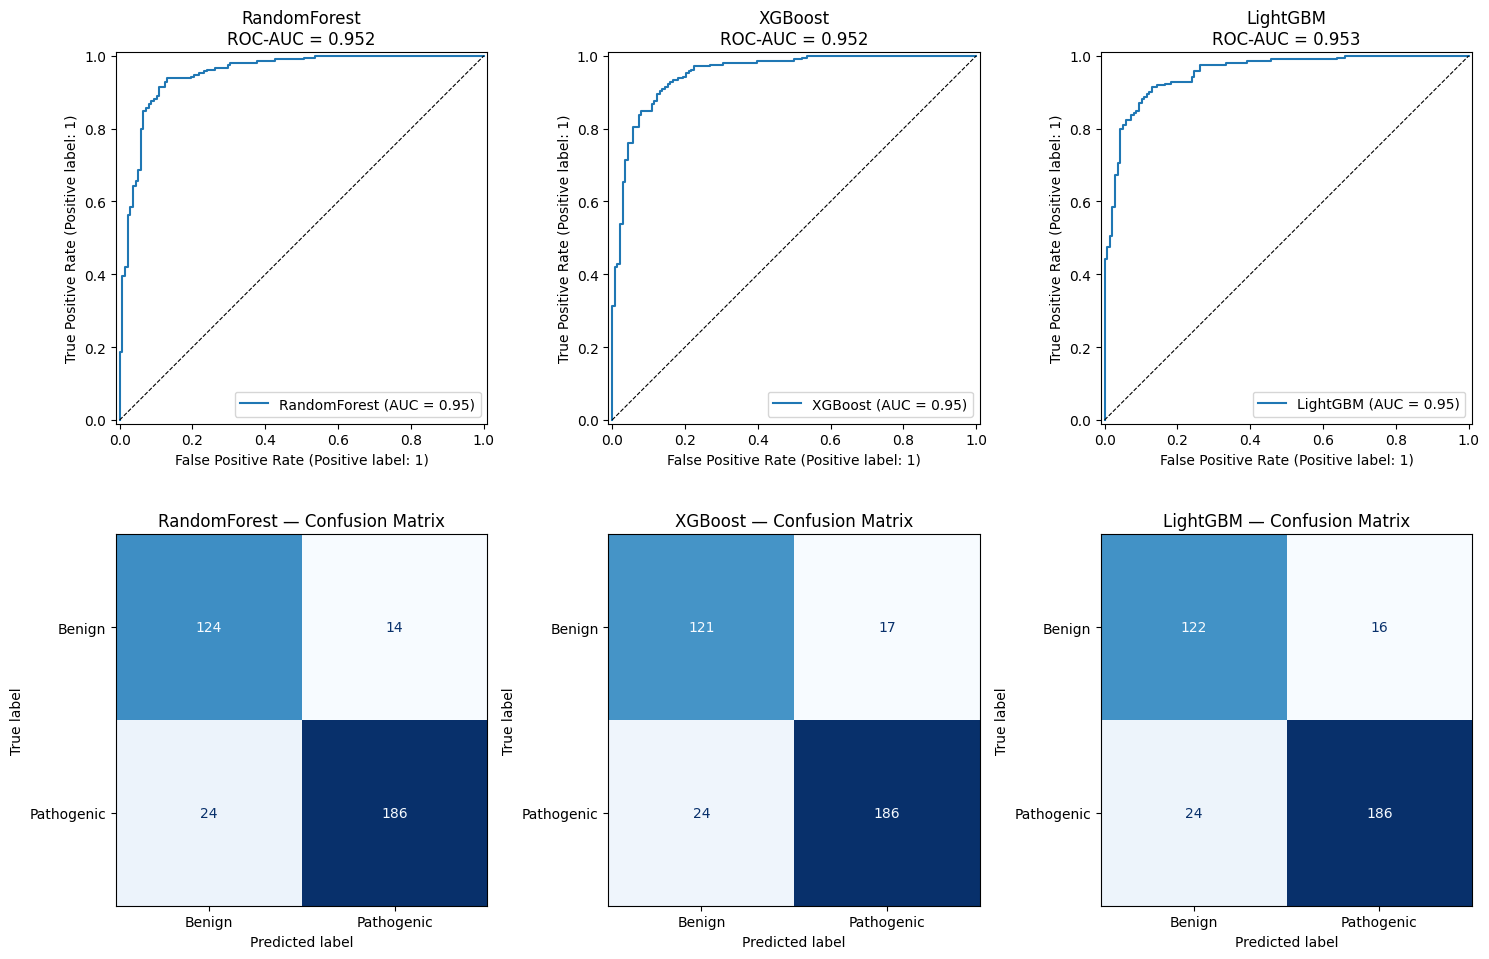

       Model  ROC-AUC  Avg Precision
    LightGBM 0.953278       0.968323
     XGBoost 0.952381       0.965214
RandomForest 0.951691       0.962219


In [22]:

# ── Evaluation plots ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, len(models), figsize=(5 * len(models), 10))

for col_idx, (name, res) in enumerate(results.items()):
    # ROC curve
    RocCurveDisplay.from_predictions(
        y_test, res["y_prob"], name=name, ax=axes[0, col_idx]
    )
    axes[0, col_idx].set_title(f"{name}\nROC-AUC = {res['roc_auc']:.3f}")
    axes[0, col_idx].plot([0,1],[0,1],"k--", lw=0.8)
    
    # Confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test, res["y_pred"],
        display_labels=["Benign", "Pathogenic"],
        ax=axes[1, col_idx], cmap="Blues", colorbar=False
    )
    axes[1, col_idx].set_title(f"{name} — Confusion Matrix")

plt.tight_layout()
plt.savefig(r"c:\Users\Umut\Desktop\missense_classificaiton\model_evaluation.png",
            dpi=120, bbox_inches="tight")
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame([
    {"Model": k, "ROC-AUC": v["roc_auc"], "Avg Precision": v["avg_precision"]}
    for k, v in results.items()
]).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
print(summary.to_string(index=False))


In [23]:

# ── Detailed classification reports ──────────────────────────────────────────
for name, res in results.items():
    print(f"\n{'='*50}")
    print(f" {name}")
    print('='*50)
    print(classification_report(y_test, res["y_pred"],
                                 target_names=["Benign", "Pathogenic"]))



 RandomForest
              precision    recall  f1-score   support

      Benign       0.84      0.90      0.87       138
  Pathogenic       0.93      0.89      0.91       210

    accuracy                           0.89       348
   macro avg       0.88      0.89      0.89       348
weighted avg       0.89      0.89      0.89       348


 XGBoost
              precision    recall  f1-score   support

      Benign       0.83      0.88      0.86       138
  Pathogenic       0.92      0.89      0.90       210

    accuracy                           0.88       348
   macro avg       0.88      0.88      0.88       348
weighted avg       0.88      0.88      0.88       348


 LightGBM
              precision    recall  f1-score   support

      Benign       0.84      0.88      0.86       138
  Pathogenic       0.92      0.89      0.90       210

    accuracy                           0.89       348
   macro avg       0.88      0.88      0.88       348
weighted avg       0.89      0.89     

### Feature Importance (top 30 features from best tree-based model)

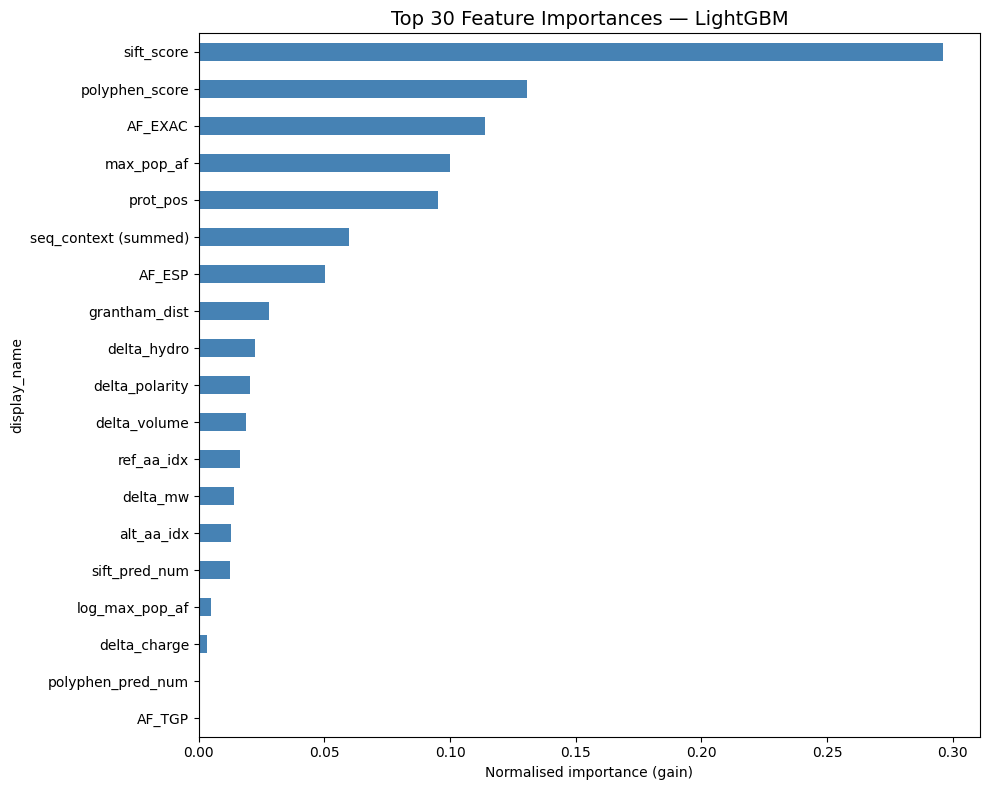

In [28]:

# ── Feature Importance (top 30, correctly named) ──────────────────────────────
best_tree_name = max(
    [n for n in results if n in ("XGBoost", "LightGBM", "RandomForest")],
    key=lambda n: results[n]["roc_auc"]
)
best_tree = results[best_tree_name]["model"]
train_feature_names = list(X_train.columns)   # ground-truth ordered names

if best_tree_name == "XGBoost":
    booster = best_tree.get_booster()
    # XGBoost ≥ 2.0 stores real names when trained on a DataFrame;
    # when trained on numpy it uses "f0", "f1", … — remap positionally.
    stored_names = booster.feature_names
    if stored_names and stored_names[0] not in ("f0", "f1", "f2"):
        # Real names already stored (DataFrame training path)
        imp_series = pd.Series(
            booster.get_score(importance_type="gain")
        ).reindex(train_feature_names, fill_value=0.0)
    else:
        # Numpy training path: "f0" → index 0
        gain_dict = booster.get_score(importance_type="gain")
        imp_series = pd.Series(
            {train_feature_names[int(k[1:])]: v
             for k, v in gain_dict.items()
             if k[1:].isdigit() and int(k[1:]) < len(train_feature_names)}
        ).reindex(train_feature_names, fill_value=0.0)

elif best_tree_name == "LightGBM":
    # booster_.feature_importance() always returns a full-length positional array,
    # but feature_name() returns "Column_0" etc. when trained on numpy.
    # Use positional mapping — guaranteed to be correct.
    imp_arr = best_tree.booster_.feature_importance(importance_type="gain")
    if len(imp_arr) == len(train_feature_names):
        imp_series = pd.Series(imp_arr, index=train_feature_names)
    else:
        # Fallback: map by stored name (should never happen in normal usage)
        feat_names = best_tree.booster_.feature_name()
        imp_series = pd.Series(dict(zip(feat_names, imp_arr))).reindex(
            train_feature_names, fill_value=0.0
        )

else:  # RandomForest — sklearn always returns a full-length positional array
    imp_series = pd.Series(best_tree.feature_importances_, index=train_feature_names)

# Normalise to [0, 1]
total_imp = imp_series.sum()
imp_series = imp_series / total_imp if total_imp > 0 else imp_series

# Build display DataFrame
feat_imp_df = imp_series.reset_index()
feat_imp_df.columns = ["feature", "importance"]

# Collapse all ctx_ features into a single "seq_context (summed)" entry
feat_imp_df["display_name"] = feat_imp_df["feature"].apply(
    lambda f: "seq_context (summed)" if f.startswith("ctx_") else f
)
feat_imp_agg = (
    feat_imp_df.groupby("display_name", sort=False)["importance"]
    .sum()
    .sort_values(ascending=False)
    .head(30)
    .sort_values(ascending=True)   # ascending for horizontal bar readability
)

fig, ax = plt.subplots(figsize=(10, 8))
feat_imp_agg.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title(f"Top 30 Feature Importances — {best_tree_name}", fontsize=14)
ax.set_xlabel("Normalised importance (gain)")
ax.set_xlim(left=0)
plt.tight_layout()
plt.savefig(r"c:\Users\Umut\Desktop\missense_classificaiton\feature_importance.png",
            dpi=120, bbox_inches="tight")
plt.show()


In [25]:

# ── Cross-validated AUC (5-fold stratified) ───────────────────────────────────
from sklearn.model_selection import cross_val_score

print("5-fold stratified cross-validation (takes a few minutes) …\n")
X_imp = imputer.transform(X)

for name, res in results.items():
    model = res["model"]
    if isinstance(model, Pipeline):
        scores = cross_val_score(model, X, y, cv=5,
                                  scoring="roc_auc", n_jobs=-1)
    else:
        scores = cross_val_score(model, X_imp, y, cv=5,
                                  scoring="roc_auc", n_jobs=-1)
    print(f"  {name:<14}  CV ROC-AUC = {scores.mean():.4f} ± {scores.std():.4f}")


5-fold stratified cross-validation (takes a few minutes) …

  RandomForest    CV ROC-AUC = 0.9518 ± 0.0245
  XGBoost         CV ROC-AUC = 0.9344 ± 0.0294
  LightGBM        CV ROC-AUC = 0.9359 ± 0.0291


In [26]:

# ── Save best model + imputer ─────────────────────────────────────────────────
import pickle

best_name  = max(results, key=lambda n: results[n]["roc_auc"])
best_model = results[best_name]["model"]

model_path = r"c:\\Users\\Umut\Desktop\\missense_classificaiton\\best_model.pkl"
with open(model_path, "wb") as fh:
    pickle.dump({"model": best_model, "imputer": imputer,
                 "features": ALL_FEATS, "model_name": best_name}, fh)

print(f"✓ Best model saved: {best_name}  (ROC-AUC = {results[best_name]['roc_auc']:.4f})")
print(f"  Path: {model_path}")


✓ Best model saved: LightGBM  (ROC-AUC = 0.9533)
  Path: c:\\Users\\Umut\Desktop\\missense_classificaiton\\best_model.pkl


---
## Appendix — Exploratory Data Analysis

Run this section any time after Step 4 to get a feel for the data distribution.

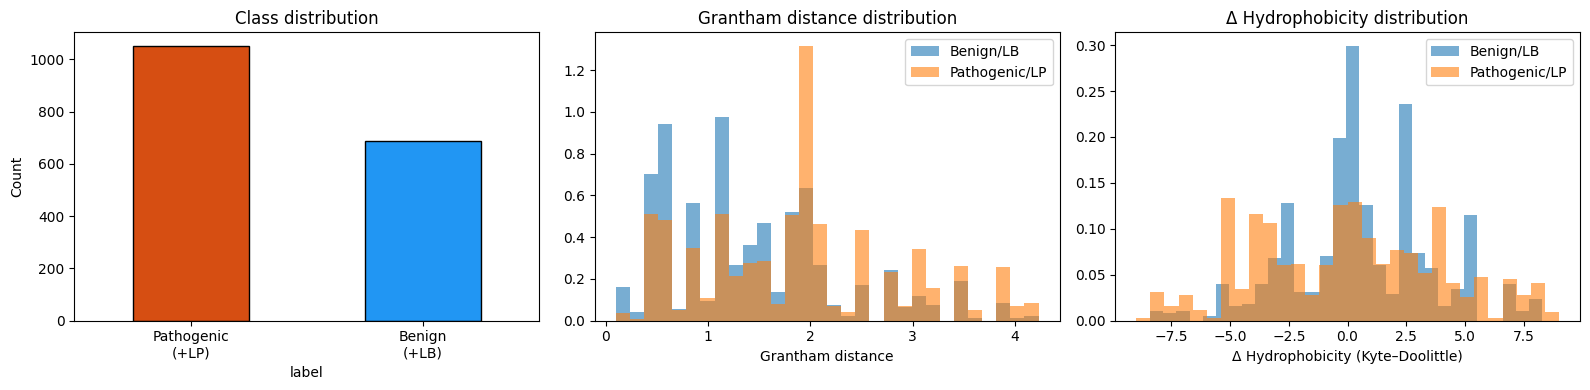

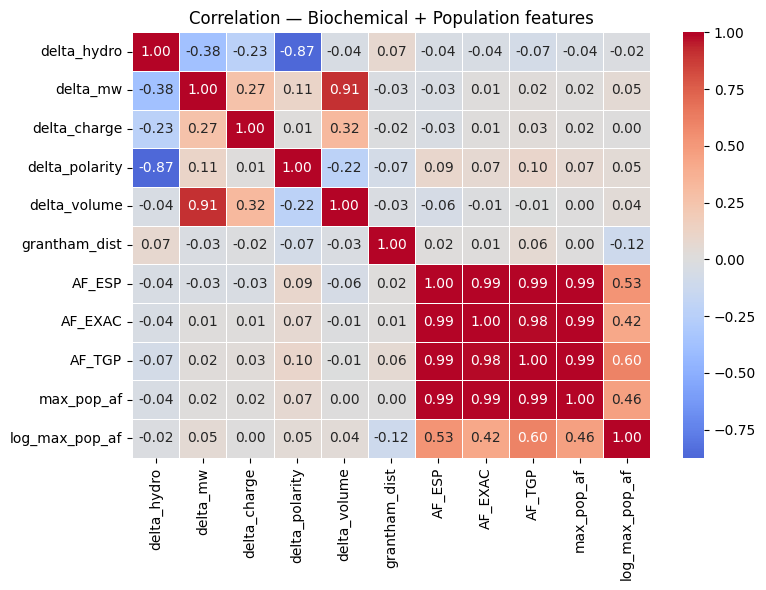

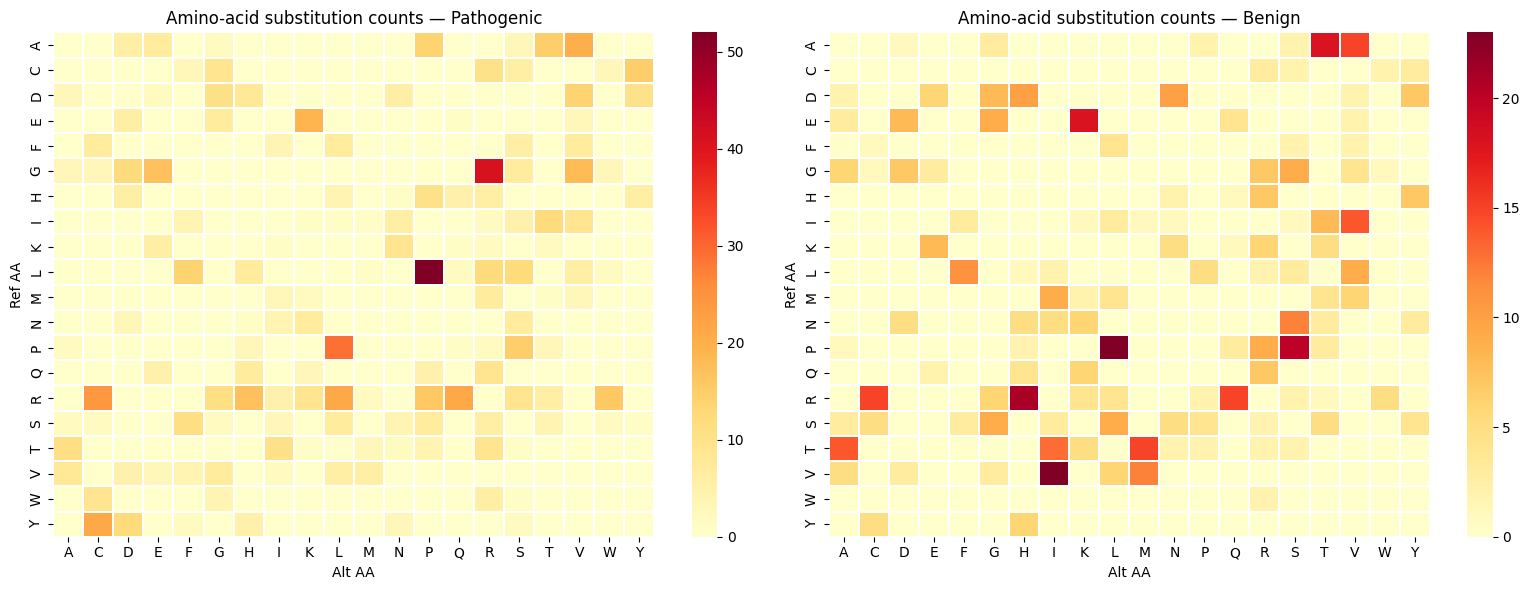

In [27]:

# ── Class balance ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Label distribution
df["label"].value_counts().rename({1: "Pathogenic\n(+LP)", 0: "Benign\n(+LB)"}).plot(
    kind="bar", ax=axes[0], color=["#d64e12","#2196F3"], edgecolor="k"
)
axes[0].set_title("Class distribution")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

# 2. Grantham distance distribution by class
for lbl, grp in df.groupby("label"):
    label_name = "Pathogenic/LP" if lbl == 1 else "Benign/LB"
    axes[1].hist(grp["grantham_dist"].dropna(), bins=30, alpha=0.6,
                 label=label_name, density=True)
axes[1].set_title("Grantham distance distribution")
axes[1].set_xlabel("Grantham distance")
axes[1].legend()

# 3. Δ Hydrophobicity by class
for lbl, grp in df.groupby("label"):
    label_name = "Pathogenic/LP" if lbl == 1 else "Benign/LB"
    axes[2].hist(grp["delta_hydro"].dropna(), bins=30, alpha=0.6,
                 label=label_name, density=True)
axes[2].set_title("Δ Hydrophobicity distribution")
axes[2].set_xlabel("Δ Hydrophobicity (Kyte–Doolittle)")
axes[2].legend()

plt.tight_layout()
plt.savefig(r"c:\Users\Umut\Desktop\missense_classificaiton\eda_overview.png",
            dpi=120, bbox_inches="tight")
plt.show()

# ── Correlation matrix for biochemical features ───────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 6))
corr_feats = BIOCHEM_FEATS + POP_FEATS
corr_data  = df[corr_feats].apply(pd.to_numeric, errors="coerce").corr()
sns.heatmap(corr_data, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax2)
ax2.set_title("Correlation — Biochemical + Population features")
plt.tight_layout()
plt.show()

# ── AA substitution heatmap ───────────────────────────────────────────────────
path_pairs   = df[df["label"] == 1][["ref_aa","alt_aa"]].dropna()
benign_pairs = df[df["label"] == 0][["ref_aa","alt_aa"]].dropna()

def make_sub_matrix(pairs):
    mat = pd.DataFrame(0, index=list(AA_ORDER), columns=list(AA_ORDER))
    for _, r in pairs.iterrows():
        if r.ref_aa in AA_ORDER and r.alt_aa in AA_ORDER:
            mat.loc[r.ref_aa, r.alt_aa] += 1
    return mat

fig3, axes3 = plt.subplots(1, 2, figsize=(16, 6))
for ax3, (pairs, title) in zip(axes3, [(path_pairs, "Pathogenic"),
                                        (benign_pairs, "Benign")]):
    mat = make_sub_matrix(pairs)
    sns.heatmap(mat, cmap="YlOrRd", ax=ax3, cbar=True, linewidths=0.3,
                annot=False)
    ax3.set_title(f"Amino-acid substitution counts — {title}")
    ax3.set_xlabel("Alt AA")
    ax3.set_ylabel("Ref AA")
plt.tight_layout()
plt.show()
